## **Unsupervised Learning**

#### **Clustering**: Grouping data with similar properties without explicit information about data.

**Key Terms** : Mean&centeroid, Distance(Euclidean), Variancs and Spread

##### **1. K-Mean Clustering:** K-Means Clustering is an unsupervised machine learning algorithm used to divide a dataset into K distinct clusters based on the similarity of data points.

**Steps**
- Choose the number of clusters (K).
- Randomly initialize K centroids.
- Assign each data point to the nearest centroid.
- Recalculate the centroid of each cluster by taking the mean of all points assigned to it.
- Repeat steps 3 and 4 until the centroids no longer change significantly or a maximum number of iterations is reached.

**Elbow Method in K-Means Clustering :** The Elbow Method is used to find the optimal number of clusters (K) for K-Means.

Main Idea: For different values of K, calculate the WCSS (Within-Cluster Sum of Squares), also called inertia.





As K increases:

    WCSS always decreases.
    Initially, it decreases sharply.
    After a certain point, the improvement becomes small.
That turning point looks like an elbow (💪). We choose that value as the optimal K.

  Customer  Age  Spending  Group
0    Mukul   20       200      1
1    Karan   19       250      1
2    Raman   27       500      0
3   Deepak   30       400      0
4    Priya   18       240      1
5   Khushi   19       220      1


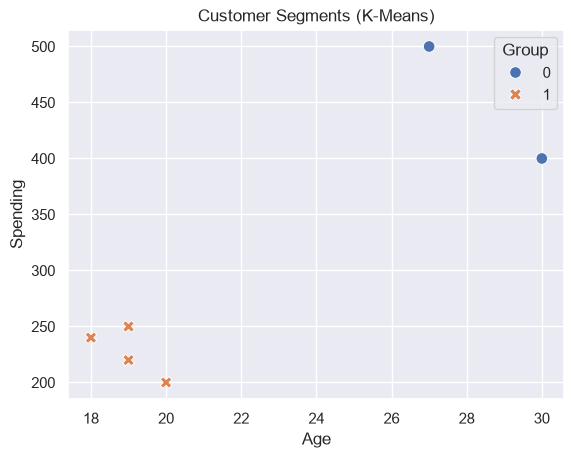

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Sample Dataset
data = {
    'Customer': ['Mukul','Karan','Raman','Deepak','Priya','Khushi'],
    'Age':[20,19,27,30,18,19],
    'Spending':[200,250,500,400,240,220]
}

df = pd.DataFrame(data)

X = df[['Age','Spending']]

# 2. KMeans Clustering
model = KMeans(n_clusters=2, random_state=42, n_init=10)
df['Group'] = model.fit_predict(X)  #This line added a column named Group (Clustering Column) in df
print(df)

# #3. Plotting each group with its own color
# plt.Figure(figsize=(6,5))
# for group in df['Group'].unique():
#     Group_data = df[df['Group'] == group]
#     # print(Group_data)
#     plt.scatter(Group_data['Age'],Group_data['Spending'],label=f'Group{group}')
# plt.title('Customers Sengements (K-Mean)')
# plt.xlabel('Age')
# plt.ylabel('Spending Score')
# plt.legend()
# plt.grid(True)
# plt.show()

#Using seaborn
sns.set_theme()
sns.scatterplot(data=df,x = 'Age', y = 'Spending',
                hue='Group',style='Group',s=70)
plt.title('Customer Segments (K-Means)')
plt.show()


#### Principal Component Analysis (PCA)

**PCA (Principal Component Analysis) is an unsupervised dimensionality reduction technique.**

Its main purpose is to reduce the number of features while preserving as much important information (variance) as possible.

    PCA transforms the original features into a smaller number of new features called Principal Components.
Principal Components are new features created as combinations of the original features.
- PC1 captures the maximum variance in the data.
- PC2 captures the next highest variance.
- PC2 is orthogonal (perpendicular) to PC1.
- PC3 captures the next remaining variance.
- Principal components are ordered by the amount of variance they explain.


Variance captured by each PCA components:
[84.076  8.817]
       PCA1      PCA2
0 -3.027351 -0.351942
1 -0.736933  0.153965
2 -0.812672 -0.336306
3  0.395472  1.242357
4  1.415834 -0.179039
5  2.765651 -0.529035


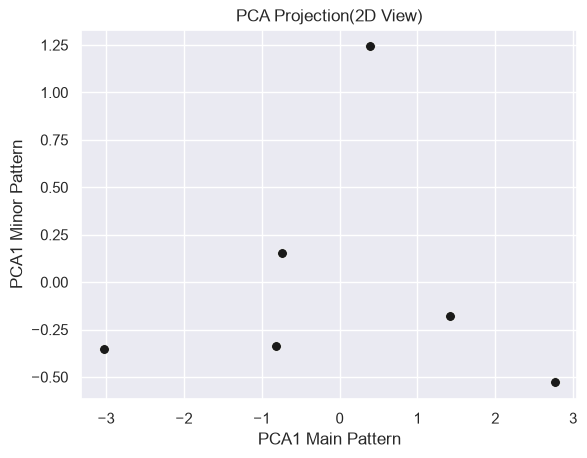

In [66]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Sample Dataset
data = {
    'Age': [20,25,30,35,40,50],
    'Income': [30000,40000,55000,60000,65000,80000],
    'Spending':[34,64,50,46,76,85],
    'Saving':[100,300,200,400,350,370]
    }

df = pd.DataFrame(data)

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
# print(scaled_data)

pca = PCA(n_components=2, random_state=42)
pca_data = pca.fit_transform(scaled_data)

pca_df=pd.DataFrame(pca_data,columns=['PCA1','PCA2'])

explained_variance = pca.explained_variance_ratio_
print('Variance captured by each PCA components:')
print(np.round(explained_variance*100,3))
print(pca_df)

sns.set_theme()
sns.scatterplot(data = pca_df,x='PCA1',y='PCA2',s=50,c='k')
plt.title('PCA Projection(2D View)')
plt.xlabel('PCA1 Main Pattern')
plt.ylabel('PCA1 Minor Pattern')
plt.show()